# 📊 Code Metrics Dataset

    O dataset contém métricas de código de um projeto de software, com foco em qualidade e manutenibilidade.
    Possui 509.426 registros e 53 colunas, onde cada linha representa um arquivo, classe ou tipo.
    Inclui métricas como complexidade ciclomática, linhas de código e acoplamento entre classes.
    Apresenta indicadores de dependência, como fan-in e fan-out.
    Contém métricas de herança, como profundidade (DIT) e número de subclasses (NOC).
    Avalia a complexidade das classes por meio do WMC (Weighted Methods per Class).
    Inclui métricas de coesão, como LCOM e sua versão modificada.
    Possui a variável “refactoring”, que indica se houve refatoração no código.
    Pode ser usado para identificar problemas estruturais e pontos de melhoria no código.
    Também é útil para análises preditivas e acompanhamento da evolução da qualidade do software.

    https://www.kaggle.com/datasets/amalsalilan/code-metrics-dataset-softwareprojectstructure/data

## 📊 Descrição das Colunas - Code Metrics Dataset

### 🔧 Identificação e contexto

- **refactoring**: Indica se houve refatoração (0 = não, 1 = sim).
- **file**: Nome do arquivo fonte.
- **class**: Nome da classe analisada.
- **type**: Tipo da entidade (ex: classe, método, arquivo).

---

### 🔗 Métricas de Acoplamento (Coupling)

- **cbo (Coupling Between Objects)**: Número de classes às quais esta classe está acoplada.
- **cboModified**: Versão modificada do CBO considerando herança.
- **fanin**: Número de classes que dependem desta classe (dependências de entrada).
- **fanout**: Número de classes das quais esta classe depende (dependências de saída).

---

### 🧠 Métricas de Complexidade e Herança (CK Metrics)

- **wmc (Weighted Methods per Class)**: Soma da complexidade ciclomática dos métodos da classe.
- **dit (Depth of Inheritance Tree)**: Profundidade da árvore de herança.
- **noc (Number of Children)**: Número de subclasses diretas.
- **rfc (Response For a Class)**: Número de métodos que podem ser executados em resposta a uma chamada.

---

### 🧩 Métricas de Coesão

- **lcom (Lack of Cohesion of Methods)**: Mede a falta de coesão entre métodos (quanto maior, pior).
- **lcom\***: Versão modificada do LCOM.
- **tcc (Tight Class Cohesion)**: Grau de coesão forte entre métodos (0 a 1).
- **lcc (Loose Class Cohesion)**: Coesão considerando conexões indiretas.

---

### 🔢 Métricas de Métodos

- **totalMethodsQty**: Total de métodos na classe.
- **staticMethodsQty**: Métodos estáticos.
- **publicMethodsQty**: Métodos públicos.
- **privateMethodsQty**: Métodos privados.
- **protectedMethodsQty**: Métodos protegidos.
- **defaultMethodsQty**: Métodos com visibilidade padrão (package-private).
- **visibleMethodsQty**: Métodos visíveis externamente.
- **abstractMethodsQty**: Métodos abstratos.
- **finalMethodsQty**: Métodos finais.
- **synchronizedMethodsQty**: Métodos sincronizados.

---

### 🧱 Métricas de Atributos (Fields)

- **totalFieldsQty**: Total de atributos.
- **staticFieldsQty**: Atributos estáticos.
- **publicFieldsQty**: Atributos públicos.
- **privateFieldsQty**: Atributos privados.
- **protectedFieldsQty**: Atributos protegidos.
- **defaultFieldsQty**: Atributos com visibilidade padrão.
- **finalFieldsQty**: Atributos finais.
- **synchronizedFieldsQty**: Atributos sincronizados.

---

### 📏 Métricas de Tamanho e Estrutura

- **nosi (Number of Statements)**: Número de instruções.
- **loc (Lines of Code)**: Linhas de código.
- **returnQty**: Número de instruções `return`.
- **loopQty**: Número de loops (for, while, etc.).
- **comparisonsQty**: Número de comparações (if, switch, etc.).
- **tryCatchQty**: Quantidade de blocos try/catch.
- **parenthesizedExpsQty**: Expressões com parênteses.
- **stringLiteralsQty**: Literais de string.
- **numbersQty**: Literais numéricos.
- **assignmentsQty**: Atribuições.
- **mathOperationsQty**: Operações matemáticas.
- **variablesQty**: Variáveis declaradas.

---

### 🧬 Complexidade Estrutural

- **maxNestedBlocksQty**: Profundidade máxima de blocos aninhados.
- **anonymousClassesQty**: Número de classes anônimas.
- **innerClassesQty**: Número de classes internas.
- **lambdasQty**: Número de expressões lambda.

---

### 🧠 Métricas Léxicas

- **uniqueWordsQty**: Quantidade de palavras únicas no código.
- **modifiers**: Número de modificadores utilizados (public, static, etc.).

---

### 📜 Logging e Observabilidade

- **logStatementsQty**: Número de instruções de log.

---

## 📌 Observações

- Métricas como **CBO, WMC, DIT, RFC e LCOM** fazem parte do conjunto clássico de métricas CK, amplamente usadas para avaliar qualidade e manutenibilidade de software.
- Métricas de tamanho (LOC, métodos, atributos) ajudam a entender a escala do código.
- Métricas estruturais e de complexidade estão diretamente relacionadas a bugs e dificuldade de manutenção.


In [19]:
import sys

# Instala as dependências no mesmo ambiente Python do kernel atual
%pip install -q --break-system-packages pandas numpy matplotlib seaborn

print("Dependências instaladas com sucesso.")

Note: you may need to restart the kernel to use updated packages.
Dependências instaladas com sucesso.


In [20]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, List

# Configuração visual global
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style="whitegrid", palette="muted")

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.



## Estrutura do Código (POO)

O código está organizado em **três classes** com responsabilidades bem definidas, seguindo o princípio de responsabilidade única (**SRP — Single Responsibility Principle**):

| Classe | Responsabilidade |
|---|---|
| `DataLoader` | Carrega o dataset a partir de uma URL e expõe informações básicas sobre ele |
| `DataPreprocessor` | Aplica limpeza e transformações necessárias nos dados brutos |
| `Visualizer` | Contém um método por grupo de métricas, gerando os gráficos mais adequados a cada tipo |

Essa separação facilita **reutilização, testabilidade e manutenção** do código.


In [21]:

class DataLoader:
    """Responsável por carregar e inspecionar o dataset a partir de uma URL."""

    def __init__(self, url: str):
        self.url = url
        self._df: Optional[pd.DataFrame] = None

    def load(self) -> pd.DataFrame:
        self._df = pd.read_csv(self.url)
        print(f"Dataset carregado: {self._df.shape[0]:,} linhas × {self._df.shape[1]} colunas")
        return self._df

    def show_info(self) -> None:
        if self._df is None:
            raise RuntimeError("Chame load() antes de show_info().")
        print("=== Tipos de dados ===")
        print(self._df.dtypes.value_counts().to_string())
        print("\n=== Valores ausentes ===")
        miss = self._df.isnull().sum()
        if miss.any():
            print(miss[miss > 0].sort_values(ascending=False).to_string())
        else:
            print("  Nenhum valor ausente encontrado.")
        print("\n=== Distribuição do target 'refactoring' ===")
        counts = self._df['refactoring'].value_counts().sort_index()
        for k, v in counts.items():
            label = "Refatorado" if k == 1 else "Não Refatorado"
            print(f"  {label} ({k}): {v:,} ({v / len(self._df) * 100:.1f}%)")

    @property
    def df(self) -> pd.DataFrame:
        if self._df is None:
            raise RuntimeError("Chame load() antes de acessar .df")
        return self._df


In [22]:

class DataPreprocessor:
    """Responsável pelo pré-processamento dos dados."""

    IDENTIFIER_COLS = ["file", "class", "type"]
    TARGET_COL = "refactoring"

    def __init__(self, df: pd.DataFrame):
        self._raw = df
        self._processed: Optional[pd.DataFrame] = None

    def preprocess(self) -> pd.DataFrame:
        df = self._raw.copy()

        # 0. Garantir target numérico (evita incompatibilidades de paleta no seaborn)
        if self.TARGET_COL in df.columns:
            df[self.TARGET_COL] = pd.to_numeric(df[self.TARGET_COL], errors='coerce')
            target_missing = int(df[self.TARGET_COL].isnull().sum())
            if target_missing > 0:
                mode_target = int(df[self.TARGET_COL].mode(dropna=True).iloc[0])
                df[self.TARGET_COL] = df[self.TARGET_COL].fillna(mode_target)
                print(f"[0] Target com valores inválidos tratado: {target_missing} célula(s) preenchida(s) com a moda ({mode_target})")
            df[self.TARGET_COL] = df[self.TARGET_COL].astype(int)

        # 1. Remover colunas identificadoras (strings sem valor analítico direto)
        cols_to_drop = [c for c in self.IDENTIFIER_COLS if c in df.columns]
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"[1] Colunas identificadoras removidas: {cols_to_drop}")

        # 2. Preencher valores ausentes das features numéricas com mediana (robusta a outliers)
        num_cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c != self.TARGET_COL
        ]
        missing_total = int(df[num_cols].isnull().sum().sum())
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
        print(f"[2] Valores ausentes preenchidos com mediana: {missing_total:,} célula(s) tratada(s)")

        self._processed = df
        print(f"\nShape final: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
        return df

    @property
    def processed(self) -> pd.DataFrame:
        if self._processed is None:
            raise RuntimeError("Chame preprocess() antes de acessar .processed")
        return self._processed

    def get_features(self) -> pd.DataFrame:
        """Retorna as colunas de features, sem o target."""
        return self._processed.drop(columns=[self.TARGET_COL], errors='ignore')


In [23]:

class Visualizer:
    """
    Responsável pelas visualizações exploratórias do dataset de métricas de código.
    Cada método corresponde a um grupo de métricas com o tipo de gráfico mais adequado.
    """

    COUPLING_COLS   = ['cbo', 'cboModified', 'fanin', 'fanout']
    COMPLEXITY_COLS = ['wmc', 'dit', 'noc', 'rfc']
    COHESION_COLS   = ['lcom', 'lcom*', 'tcc', 'lcc']
    SIZE_COLS       = ['loc', 'nosi', 'returnQty', 'loopQty', 'comparisonsQty', 'tryCatchQty']
    METHOD_COLS     = ['totalMethodsQty', 'staticMethodsQty', 'publicMethodsQty',
                       'privateMethodsQty', 'protectedMethodsQty', 'abstractMethodsQty']
    FIELD_COLS      = ['totalFieldsQty', 'staticFieldsQty', 'publicFieldsQty',
                       'privateFieldsQty', 'protectedFieldsQty', 'finalFieldsQty']

    PALETTE   = {'0': "#4878CF", '1': "#D65F5F"}
    SAMPLE_N  = 10_000

    def __init__(self, df: pd.DataFrame, target_col: str = "refactoring"):
        self.df = df
        self.target = target_col

    def _get_cols(self, desired: List[str]) -> List[str]:
        return [c for c in desired if c in self.df.columns]

    def _sample(self, n: int = None) -> pd.DataFrame:
        n = n or self.SAMPLE_N
        return self.df.sample(n=n, random_state=42) if len(self.df) > n else self.df

    def _cap(self, df: pd.DataFrame, cols: List[str], p: float = 0.95) -> pd.DataFrame:
        """Limita valores extremos ao percentil p para melhorar a visualização."""
        df = df.copy()
        for col in cols:
            df[col] = df[col].clip(upper=df[col].quantile(p))
        return df

    def _as_target_str(self, df: pd.DataFrame) -> pd.DataFrame:
        """Normaliza target como string para compatibilidade com paleta categórica do seaborn."""
        out = df.copy()
        out[self.target] = out[self.target].astype(str)
        return out

    # -----------------------------------------------------------------------

    def plot_target_distribution(self):
        target_series = self.df[self.target].astype(str)
        counts = target_series.value_counts().sort_index()
        labels = {'0': "Não Refatorado", '1': "Refatorado"}
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle("Distribuição da Variável Target", fontsize=14, fontweight='bold')

        bars = axes[0].bar(
            [labels.get(i, i) for i in counts.index], counts.values,
            color=[self.PALETTE.get(i, "#999999") for i in counts.index],
            edgecolor='white', linewidth=1.5
        )
        for bar, val in zip(bars, counts.values):
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                         f'{val:,}', ha='center', va='bottom', fontsize=11)
        axes[0].set_ylabel("Quantidade")
        axes[0].set_title("Contagem por Classe")

        axes[1].pie(
            counts.values,
            labels=[labels.get(i, i) for i in counts.index],
            colors=[self.PALETTE.get(i, "#999999") for i in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        axes[1].set_title("Proporção por Classe (%)")
        plt.tight_layout()
        plt.show()

    def plot_coupling_metrics(self):
        cols = self._get_cols(self.COUPLING_COLS)
        if not cols:
            print("Nenhuma coluna de acoplamento encontrada.")
            return
        sample = self._as_target_str(self._cap(self._sample(), cols))
        fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
        if len(cols) == 1:
            axes = [axes]
        fig.suptitle("Métricas de Acoplamento — Refatorado vs. Não Refatorado",
                     fontsize=13, fontweight='bold')
        for ax, col in zip(axes, cols):
            sns.boxplot(data=sample, x=self.target, y=col, ax=ax,
                        palette=self.PALETTE, width=0.5,
                        flierprops={'markersize': 2, 'alpha': 0.3})
            ax.set_xticklabels(["Não Refat.", "Refat."])
            ax.set_xlabel("")
            ax.set_title(col)
        plt.tight_layout()
        plt.show()

    def plot_complexity_metrics(self):
        cols = self._get_cols(self.COMPLEXITY_COLS)
        if not cols:
            print("Nenhuma coluna de complexidade encontrada.")
            return
        sample = self._as_target_str(self._cap(self._sample(), cols))
        fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
        if len(cols) == 1:
            axes = [axes]
        fig.suptitle("Métricas de Complexidade e Herança — Refatorado vs. Não Refatorado",
                     fontsize=13, fontweight='bold')
        for ax, col in zip(axes, cols):
            sns.violinplot(data=sample, x=self.target, y=col, ax=ax,
                           palette=self.PALETTE, inner='quartile', cut=0)
            ax.set_xticklabels(["Não Refat.", "Refat."])
            ax.set_xlabel("")
            ax.set_title(col)
        plt.tight_layout()
        plt.show()

    def plot_cohesion_metrics(self):
        cols = self._get_cols(self.COHESION_COLS)
        if not cols:
            print("Nenhuma coluna de coesão encontrada.")
            return
        sample = self._as_target_str(self._cap(self._sample(), cols))
        fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
        if len(cols) == 1:
            axes = [axes]
        fig.suptitle("Métricas de Coesão — Refatorado vs. Não Refatorado",
                     fontsize=13, fontweight='bold')
        for ax, col in zip(axes, cols):
            sns.boxplot(data=sample, x=self.target, y=col, ax=ax,
                        palette=self.PALETTE, width=0.5,
                        flierprops={'markersize': 2, 'alpha': 0.3})
            sns.stripplot(data=sample, x=self.target, y=col, ax=ax,
                          palette=self.PALETTE, alpha=0.15, size=2, jitter=True)
            ax.set_xticklabels(["Não Refat.", "Refat."])
            ax.set_xlabel("")
            ax.set_title(col)
        plt.tight_layout()
        plt.show()

    def plot_size_metrics(self):
        cols = self._get_cols(self.SIZE_COLS)
        if not cols:
            print("Nenhuma coluna de tamanho encontrada.")
            return
        plot_df = self._as_target_str(self.df)
        n_cols_grid = 3
        n_rows_grid = -(-len(cols) // n_cols_grid)
        fig, axes = plt.subplots(n_rows_grid, n_cols_grid,
                                 figsize=(5 * n_cols_grid, 4 * n_rows_grid))
        axes = axes.flatten()
        fig.suptitle("Distribuição das Métricas de Tamanho e Estrutura",
                     fontsize=13, fontweight='bold')
        for i, col in enumerate(cols):
            ax = axes[i]
            capped = self._cap(plot_df, [col])
            for t_val in ['0', '1']:
                subset = capped[capped[self.target] == t_val][col]
                ax.hist(subset, bins=50, alpha=0.6, color=self.PALETTE[t_val], density=True,
                        label="Refat." if t_val == '1' else "Não Refat.")
            ax.set_title(col)
            ax.set_xlabel("Valor")
            ax.set_ylabel("Densidade")
            ax.legend(fontsize=8)
        for j in range(len(cols), len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()

    def plot_method_comparison(self):
        cols = self._get_cols(self.METHOD_COLS + self.FIELD_COLS)
        if not cols:
            print("Nenhuma coluna de métodos/atributos encontrada.")
            return
        means = self.df.groupby(self.target)[cols].mean()
        if 0 in means.index and 1 in means.index:
            diff = (means.loc[1] - means.loc[0]).sort_values()
        elif '0' in means.index and '1' in means.index:
            diff = (means.loc['1'] - means.loc['0']).sort_values()
        else:
            raise ValueError("Target não possui classes esperadas (0 e 1).")

        fig, ax = plt.subplots(figsize=(10, max(5, len(cols) * 0.5)))
        colors = ['#D65F5F' if v > 0 else '#4878CF' for v in diff.values]
        ax.barh(diff.index, diff.values, color=colors, edgecolor='white', linewidth=0.8)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(
            "Diferença de Médias: Refatorado - Não Refatorado\n"
            "(vermelho = maior nas classes refatoradas, azul = menor)",
            fontsize=12, fontweight='bold'
        )
        ax.set_xlabel("Diferença de Média")
        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self):
        priority = self._get_cols(
            self.COUPLING_COLS + self.COMPLEXITY_COLS + self.COHESION_COLS +
            ['loc', 'nosi', 'returnQty', 'loopQty', 'totalMethodsQty', 'totalFieldsQty',
             self.target]
        )
        num_df = self.df[priority] if priority else self.df.select_dtypes(include=[np.number])
        corr = num_df.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        fig, ax = plt.subplots(figsize=(14, 10))
        sns.heatmap(
            corr, mask=mask, annot=True, fmt=".2f",
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7}
        )
        ax.set_title("Matriz de Correlação — Métricas Selecionadas e Target",
                     fontsize=13, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()



---
## 1. Carga do Dataset

O dataset é carregado diretamente da URL pública no GitHub. O `DataLoader` exibe as dimensões, tipos de dados, valores ausentes e o balanceamento do target logo após a carga.


In [24]:

URL = "https://raw.githubusercontent.com/luizfernandoandrade1/sprint-machine-learning-and-analytics/refs/heads/main/OnlyTrivial_dt.csv"

loader = DataLoader(URL)
df_raw = loader.load()
loader.show_info()


Dataset carregado: 232,468 linhas × 53 colunas
=== Tipos de dados ===
int64      47
str         3
float64     3

=== Valores ausentes ===
tcc      75066
lcc      75066
lcom*    10099

=== Distribuição do target 'refactoring' ===
  Não Refatorado (0): 112,599 (48.4%)
  Refatorado (1): 119,869 (51.6%)



---
## 2. Pré-Processamento dos Dados

### Tratamentos aplicados e motivação

| # | Tratamento | Motivação |
|---|---|---|
| 1 | **Remoção das colunas `file`, `class`, `type`** | São identificadores textuais das entidades do código-fonte. Não possuem valor analítico direto para EDA numérica. Caso fossem usados em modelos, exigiriam encoding específico (target encoding, embeddings), mas para exploração visual são irrelevantes. |
| 2 | **Preenchimento de valores ausentes com a mediana** | A mediana é robusta a outliers — característica importante em métricas de código, que costumam ter distribuições muito assimétricas (ex.: `loc`, `wmc`). A média poderia distorcer o preenchimento em colunas com caudas longas. |

> **Nota:** Não há remoção de outliers neste estágio de EDA. Os outliers são tratados visualmente através de *capping* no percentil 95 dentro de cada método de visualização, preservando os dados originais para análises futuras.


In [25]:

preprocessor = DataPreprocessor(df_raw)
df = preprocessor.preprocess()

# Instância do Visualizer usada em todas as seções seguintes
viz = Visualizer(df)


[1] Colunas identificadoras removidas: ['file', 'class', 'type']
[2] Valores ausentes preenchidos com mediana: 160,231 célula(s) tratada(s)

Shape final: 232,468 linhas × 50 colunas



---
## 3. Distribuição do Target

### Por que gráfico de barras + pizza?

O target `refactoring` é uma variável **binária discreta** (0 ou 1). Para esse tipo de dado, o gráfico de barras é o mais indicado para comparar contagens absolutas, enquanto o gráfico de pizza complementa mostrando a proporção relativa de cada classe.

É essencial visualizar o balanceamento do target logo no início, pois **datasets desbalanceados** exigem técnicas especiais durante o treinamento de modelos (ex.: SMOTE, pesos de classe, métricas como F1-Score ao invés de acurácia).


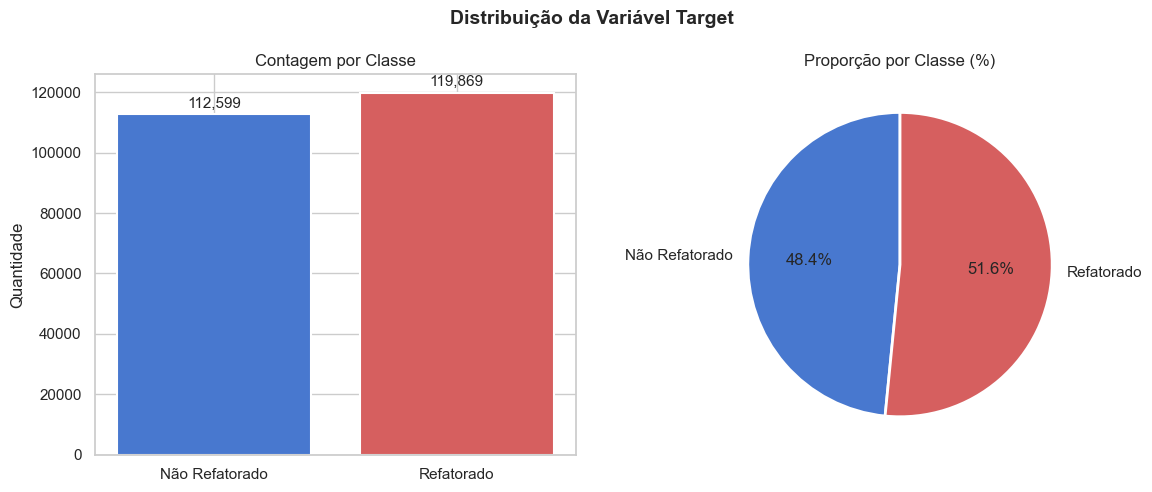

In [26]:

viz.plot_target_distribution()



---
## 4. Métricas de Acoplamento (CBO, Fan-in, Fan-out)

### Por que Boxplot?

As métricas de acoplamento (`cbo`, `cboModified`, `fanin`, `fanout`) são **variáveis contínuas com distribuições assimétricas e muitos outliers** típicos em projetos de software reais. O boxplot é ideal neste caso porque:

- Exibe de forma clara a **mediana, os quartis (IQR) e os outliers** de cada distribuição;
- Permite comparar diretamente os dois grupos (refatorado vs. não refatorado) lado a lado;
- É mais informativo que um histograma quando o objetivo é comparar grupos com distribuições diferentes.

> Os valores são *capped* no percentil 95 para evitar que outliers extremos comprimam a escala e escondam diferenças reais entre as classes.


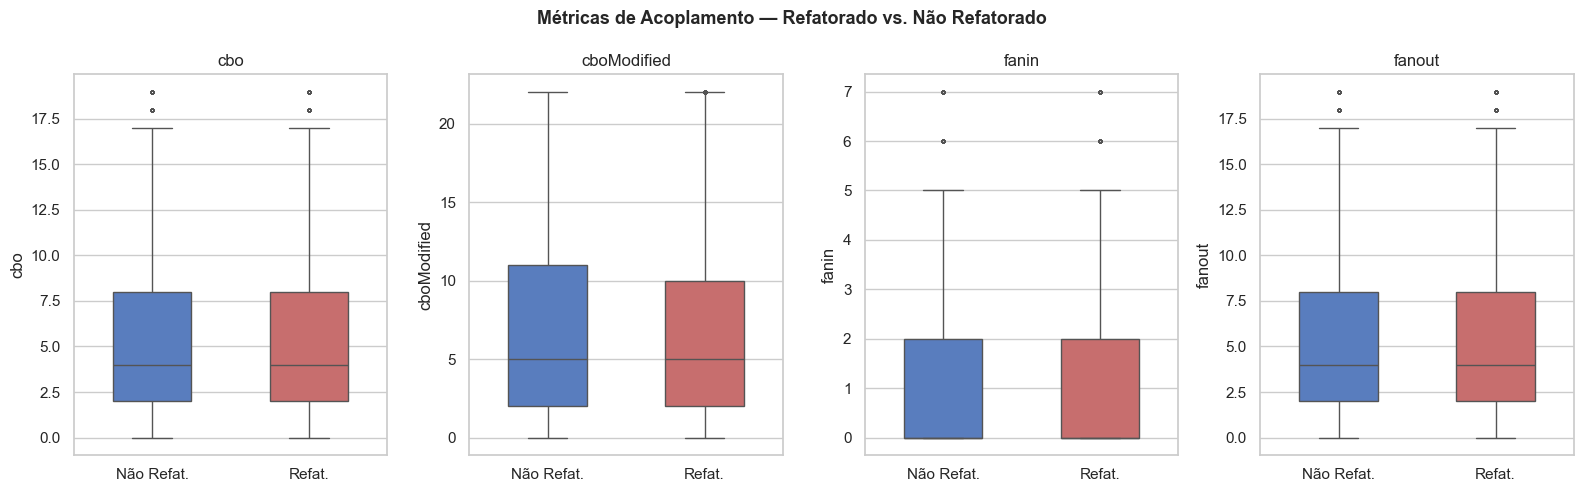

In [27]:

viz.plot_coupling_metrics()



---
## 5. Métricas de Complexidade e Herança (WMC, DIT, NOC, RFC)

### Por que Violin Plot?

O violin plot combina um **boxplot com uma estimativa de densidade de probabilidade (KDE)**, mostrando a forma completa da distribuição. Para métricas de complexidade como `wmc` (Weighted Methods per Class) e `rfc` (Response For a Class), é comum haver **múltiplos picos** na distribuição (classes muito simples × classes complexas). O violin plot revela esses padrões que um boxplot sozinho ocultaria.

- `wmc` e `rfc` tendem a ser maiores em classes refatoradas (geralmente são mais complexas e, por isso, candidatas à refatoração);
- `dit` e `noc` costumam ter valores baixos e pouco variáveis — o violin plot deixa isso evidente.


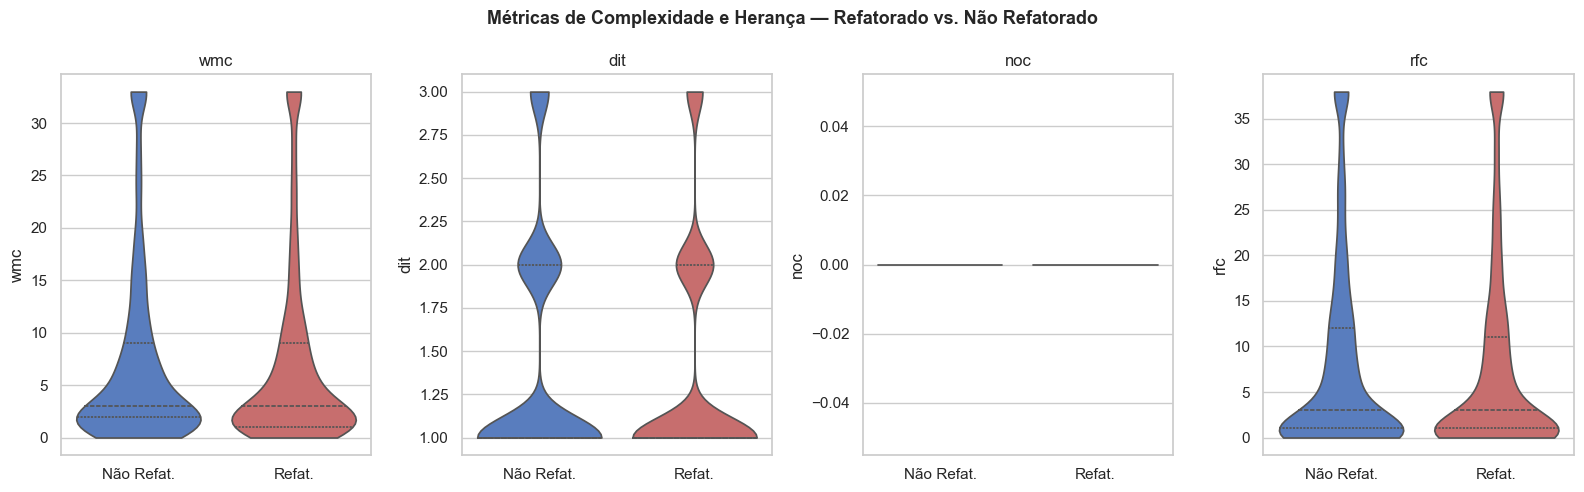

In [28]:

viz.plot_complexity_metrics()



---
## 6. Métricas de Coesão (LCOM, TCC, LCC)

### Por que Boxplot + Strip Plot sobrepostos?

As métricas de coesão como `lcom` (Lack of Cohesion of Methods) possuem **distribuições muito concentradas próximas ao zero, com caudas longas**. O boxplot com strip plot sobrepostos é a melhor escolha porque:

- O **boxplot** resume os quartis e a mediana;
- O **strip plot** (pontos semitransparentes) revela a **densidade real dos dados**, especialmente em regiões acumuladas como o zero — mostrando se a maioria das classes realmente tem baixa falta de coesão;
- A combinação evita que resumos estatísticos escondam concentrações de dados em valores específicos.

> `lcom` alto indica baixa coesão (métodos pouco relacionados), o que é comumente associado a candidatos à refatoração.


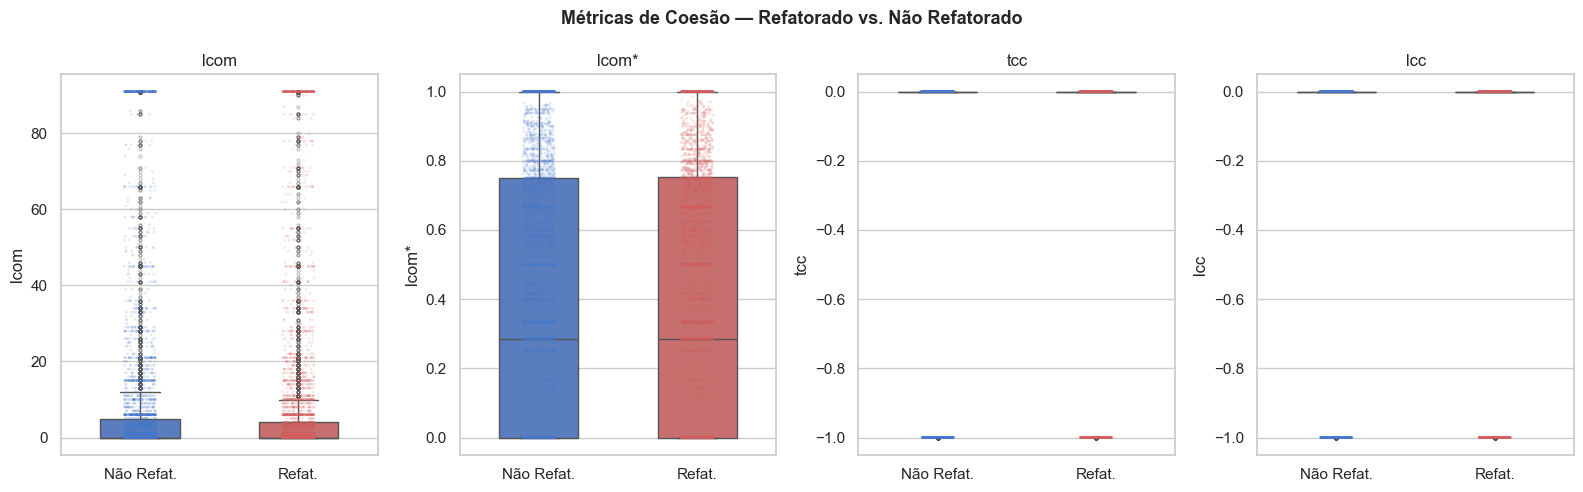

In [29]:

viz.plot_cohesion_metrics()



---
## 7. Métricas de Tamanho e Estrutura (LOC, Loops, Returns…)

### Por que Histograma com densidade?

Métricas de tamanho como `loc` (Lines of Code), `loopQty` e `comparisonsQty` são **variáveis contínuas com escala absoluta variável** — projetos pequenos têm valores próximos de zero, enquanto classes grandes podem ter centenas ou milhares de linhas. O histograma de densidade:

- Permite **sobrepor as duas classes** (refatorado / não refatorado) na mesma escala de densidade, mesmo que os grupos tenham tamanhos diferentes;
- Revela a **forma da distribuição** (uni/bimodal, assimétrica) que influencia a escolha de algoritmos e transformações;
- `density=True` normaliza cada grupo independentemente, evitando que diferenças de volume mascarem as diferenças de distribuição.


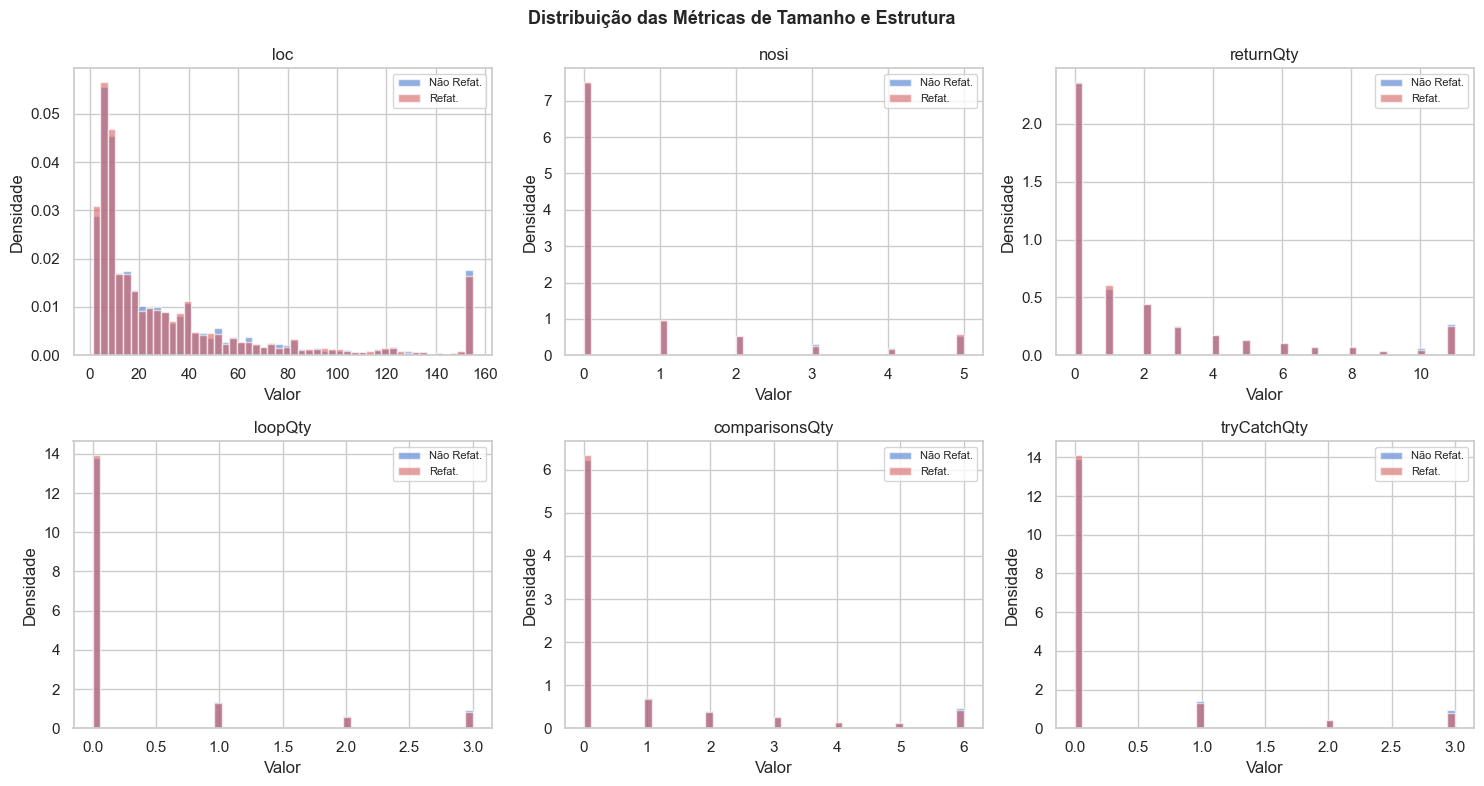

In [30]:

viz.plot_size_metrics()



---
## 8. Métodos e Atributos — Diferença entre Classes Refatoradas e Não Refatoradas

### Por que Gráfico de Barras Horizontais (Divergente)?

Este gráfico mostra a **diferença de médias** entre as classes refatoradas e não refatoradas para cada métrica de métodos e atributos. O gráfico de barras horizontais divergentes é ideal porque:

- Permite comparar **muitas variáveis ao mesmo tempo** em um único painel, de forma legível;
- A orientação horizontal acomoda rótulos longos como `protectedMethodsQty` sem sobreposição;
- A **linha de referência em zero** deixa imediatamente claro quais métricas são maiores nas classes refatoradas (barras vermelhas à direita) e quais são menores (barras azuis à esquerda);
- É mais direto que múltiplos boxplots para responder à pergunta: *"quais features discriminam melhor as duas classes?"*


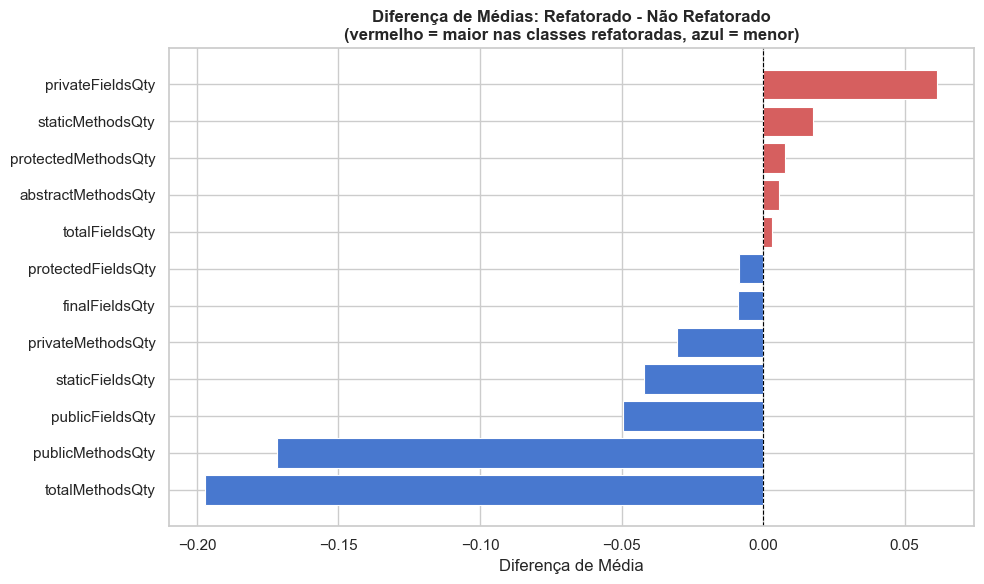

In [31]:

viz.plot_method_comparison()



---
## 9. Matriz de Correlação entre Métricas

### Por que Heatmap triangular?

A matriz de correlação usa um **heatmap com máscara triangular superior** porque:

- A correlação de Pearson é **simétrica** — exibir apenas o triângulo inferior elimina redundância e facilita a leitura;
- A **escala divergente (vermelho–branco–azul)** torna imediata a identificação de correlações fortes positivas (vermelho) e negativas (azul);
- As **anotações numéricas** permitem leitura precisa dos valores sem precisar de outra visualização.

Esta visualização é fundamental para identificar **multicolinearidade** (features altamente correlacionadas entre si), que pode degradar modelos lineares e deve ser tratada via seleção de features ou PCA. Também revela quais métricas têm maior correlação com o target `refactoring`.


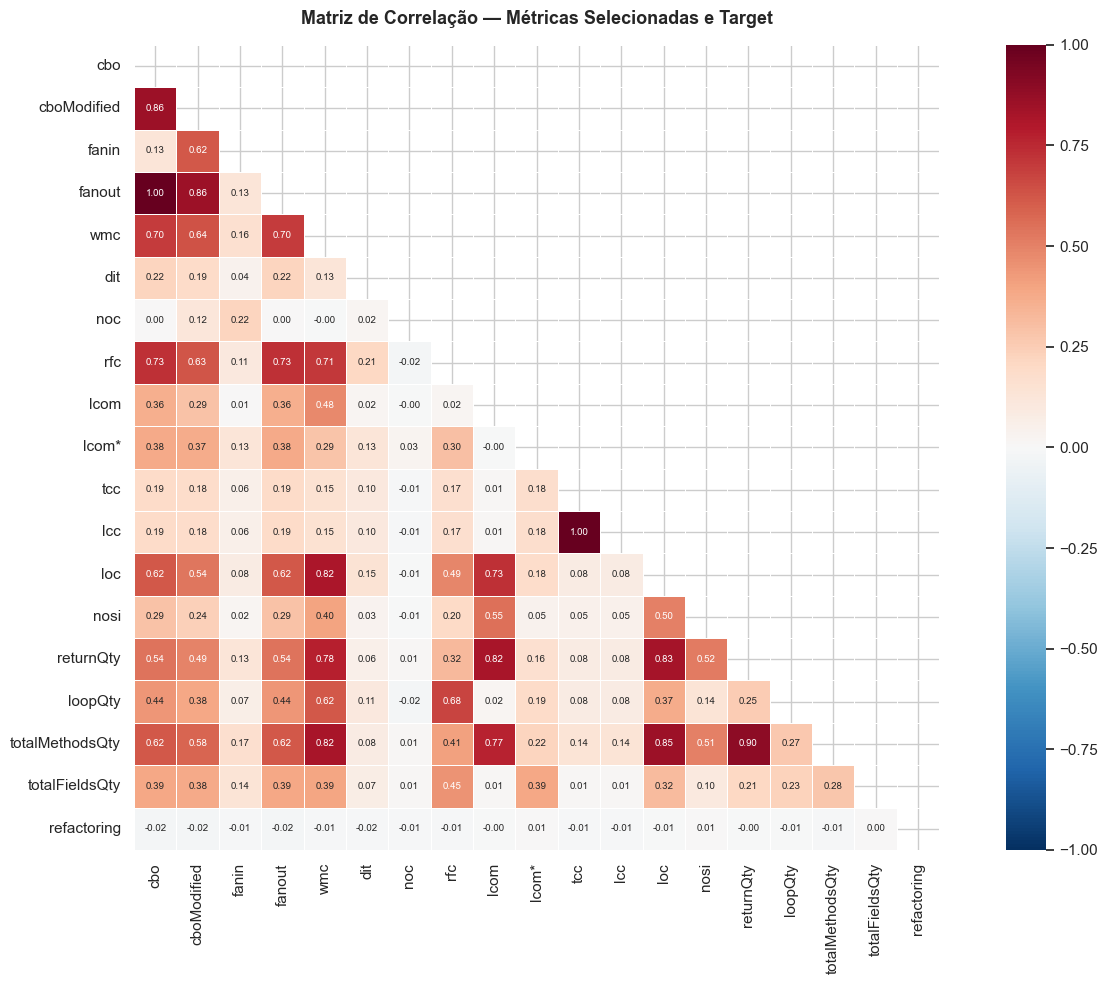

In [32]:

viz.plot_correlation_heatmap()


---
## 10. Relatório Final — Refatoração e Manutenibilidade

### Objetivo
Sintetizar quais métricas estão mais associadas à necessidade de refatoração (`refactoring`) e quais padrões têm apresentado maior risco para manutenibilidade no projeto.

### Critérios utilizados
- **Relação com refatoração:** correlação absoluta com o target binário (aproximação point-biserial).
- **Problema de manutenibilidade:** taxa de criticidade por métrica (percentis extremos).
  - Para métricas em que **alto é pior** (ex.: `wmc`, `rfc`, `cbo`, `lcom`, `loc`), considera-se crítico acima de P90.
  - Para métricas em que **baixo é pior** (`tcc`, `lcc`), considera-se crítico abaixo de P10.

### Leitura esperada
- O painel esquerdo do gráfico mostra as métricas com maior associação ao target de refatoração.
- O painel direito mostra quais métricas apresentam maior frequência de valores críticos de manutenibilidade.

### Conclusão prática
As métricas no topo dos dois rankings devem ser priorizadas em ações de melhoria (redução de complexidade, desacoplamento e aumento de coesão), pois combinam **sinal preditivo de refatoração** e **pressão de manutenção**.

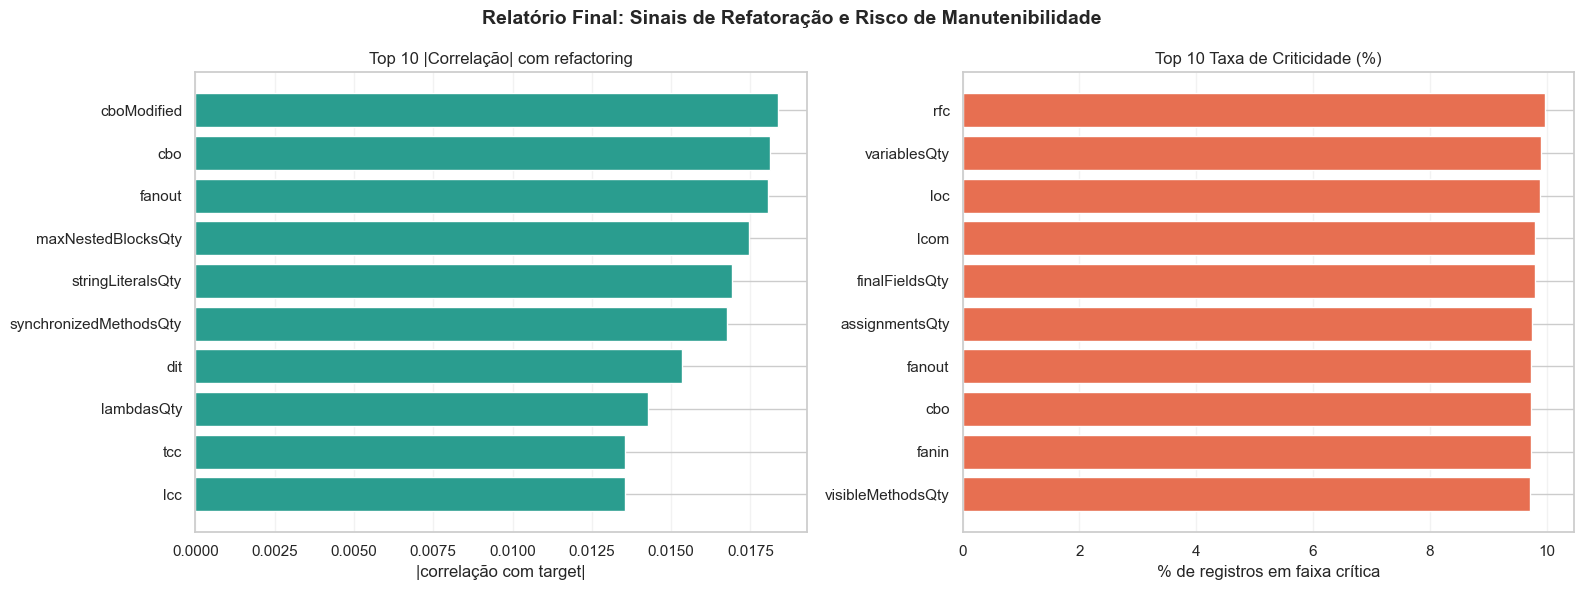

=== Métricas mais relacionadas à necessidade de refatoração ===
- cboModified: |corr| = 0.018
- cbo: |corr| = 0.018
- fanout: |corr| = 0.018
- maxNestedBlocksQty: |corr| = 0.017
- stringLiteralsQty: |corr| = 0.017
- synchronizedMethodsQty: |corr| = 0.017
- dit: |corr| = 0.015
- lambdasQty: |corr| = 0.014
- tcc: |corr| = 0.014
- lcc: |corr| = 0.014

=== Métricas com maior problema de manutenibilidade (taxa crítica) ===
- rfc: 9.97% em faixa crítica (alto é pior)
- variablesQty: 9.91% em faixa crítica (alto é pior)
- loc: 9.88% em faixa crítica (alto é pior)
- lcom: 9.80% em faixa crítica (alto é pior)
- finalFieldsQty: 9.80% em faixa crítica (alto é pior)
- assignmentsQty: 9.74% em faixa crítica (alto é pior)
- cbo: 9.73% em faixa crítica (alto é pior)
- fanout: 9.73% em faixa crítica (alto é pior)
- fanin: 9.73% em faixa crítica (alto é pior)
- visibleMethodsQty: 9.72% em faixa crítica (alto é pior)

=== Prioridade sugerida (interseção entre associação e criticidade) ===
cbo, fanout


In [37]:
class RefactoringMaintenanceReport:
    """Gera relatório de refatoração e manutenibilidade com abordagem orientada a objetos."""

    def __init__(self, data: pd.DataFrame, target_col: str = "refactoring", top_n: int = 10):
        self._raw = data.copy()
        self.target_col = target_col
        self.top_n = top_n
        self._num_df: Optional[pd.DataFrame] = None
        self.lower_is_worse = ["tcc", "lcc"]

    def _prepare_numeric_data(self) -> None:
        """Filtra e valida base numérica para análise."""
        if self.target_col not in self._raw.columns:
            raise ValueError(f"Coluna alvo '{self.target_col}' não encontrada no DataFrame processado.")

        num_df = self._raw.select_dtypes(include=[np.number]).copy()
        if self.target_col not in num_df.columns:
            num_df[self.target_col] = pd.to_numeric(self._raw[self.target_col], errors="coerce")

        num_df[self.target_col] = pd.to_numeric(num_df[self.target_col], errors="coerce")
        num_df = num_df.dropna(subset=[self.target_col])
        num_df[self.target_col] = num_df[self.target_col].astype(int)

        if num_df.shape[1] <= 1:
            raise ValueError("Não há features numéricas para análise.")

        self._num_df = num_df

    @property
    def num_df(self) -> pd.DataFrame:
        if self._num_df is None:
            self._prepare_numeric_data()
        return self._num_df

    @property
    def feature_cols(self) -> List[str]:
        return [c for c in self.num_df.columns if c != self.target_col]

    def top_related_to_refactoring(self) -> pd.Series:
        """Retorna top métricas por |correlação| com o target binário."""
        corr = self.num_df[self.feature_cols].corrwith(self.num_df[self.target_col]).dropna()
        return corr.abs().sort_values(ascending=False).head(self.top_n)

    def top_maintenance_criticality(self) -> pd.Series:
        """Retorna top métricas por taxa de criticidade em percentis extremos."""
        rates = {}
        for col in self.feature_cols:
            series = self.num_df[col].dropna()
            if series.empty:
                continue

            if col in self.lower_is_worse:
                threshold = series.quantile(0.10)
                critical_mask = series < threshold
            else:
                threshold = series.quantile(0.90)
                critical_mask = series > threshold

            rates[col] = float(critical_mask.mean() * 100)

        return pd.Series(rates).sort_values(ascending=False).head(self.top_n)

    def plot(self, related: pd.Series, critical: pd.Series) -> None:
        """Plota painel comparativo entre sinal de refatoração e criticidade."""
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(
            "Relatório Final: Sinais de Refatoração e Risco de Manutenibilidade",
            fontsize=14,
            fontweight="bold"
        )

        plot_a = related.sort_values(ascending=True)
        axes[0].barh(plot_a.index, plot_a.values, color="#2A9D8F", edgecolor="white")
        axes[0].set_title(f"Top {self.top_n} |Correlação| com refactoring")
        axes[0].set_xlabel("|correlação com target|")
        axes[0].grid(axis="x", alpha=0.25)

        plot_b = critical.sort_values(ascending=True)
        axes[1].barh(plot_b.index, plot_b.values, color="#E76F51", edgecolor="white")
        axes[1].set_title(f"Top {self.top_n} Taxa de Criticidade (%)")
        axes[1].set_xlabel("% de registros em faixa crítica")
        axes[1].grid(axis="x", alpha=0.25)

        plt.tight_layout()
        plt.show()

    def print_summary(self, related: pd.Series, critical: pd.Series) -> None:
        """Imprime resumo executivo do relatório."""
        print("=== Métricas mais relacionadas à necessidade de refatoração ===")
        for name, val in related.items():
            print(f"- {name}: |corr| = {val:.3f}")

        print("\n=== Métricas com maior problema de manutenibilidade (taxa crítica) ===")
        for name, val in critical.items():
            direction = "baixo é pior" if name in self.lower_is_worse else "alto é pior"
            print(f"- {name}: {val:.2f}% em faixa crítica ({direction})")

        priority = [m for m in related.index if m in critical.index]
        print("\n=== Prioridade sugerida (interseção entre associação e criticidade) ===")
        if priority:
            print(", ".join(priority))
        else:
            print("Sem interseção no top 10; priorize as primeiras métricas de cada ranking.")

    def run(self) -> None:
        """Executa pipeline completo do relatório."""
        related = self.top_related_to_refactoring()
        critical = self.top_maintenance_criticality()
        self.plot(related, critical)
        self.print_summary(related, critical)


report = RefactoringMaintenanceReport(df, target_col="refactoring", top_n=10)
report.run()